# Neural Network (Jaf)

### Imports

In [6]:
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import itertools, time, os, json
from sklearn.metrics import (average_precision_score, recall_score,
                             precision_recall_curve, f1_score,
                             confusion_matrix, classification_report)
import seaborn as sns
from datetime import datetime

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


### Output

In [8]:
RUN_NAME = "Jaf's NN (GridSearch, 3 Layer, Leaky ReLU)" #CHANGE IT TO WHATEVER Y'ALL WANNA NAME IT (PLS BE SPECIFIC)
RUN_DIR  = os.path.join('runs', RUN_NAME)
os.makedirs(RUN_DIR, exist_ok=True)
print(f"All outputs will be saved to: {RUN_DIR}/")

All outputs will be saved to: runs\Jaf's NN (GridSearch, 3 Layer, Leaky ReLU)/


### Load Data

In [10]:
print("\nLoading preprocessed data...")
train_df = pd.read_csv('../../preprocessed/train.csv')
val_df   = pd.read_csv('../../preprocessed/val.csv')
test_df  = pd.read_csv('../../preprocessed/test.csv')
with open('../../preprocessed/column_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)
    
target      = metadata['target']       # 'isFraud'
cat_cols    = metadata['cat_cols']
num_cols    = metadata['num_cols']
vocab_sizes = metadata['vocab_sizes']  # no. of unique indices per cat feature

cat_cols = [c for c in cat_cols if c in train_df.columns]
num_cols = [c for c in num_cols if c in train_df.columns]
print(f"Categorical features : {len(cat_cols)}")
print(f"Numerical features   : {len(num_cols)}")


Loading preprocessed data...
Categorical features : 19
Numerical features   : 252


### Dataset Object

In [11]:
class FraudDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target):
        self.cat  = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.num  = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.y    = torch.tensor(df[target].values,   dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.cat[idx], self.num[idx], self.y[idx]

### Model

In [12]:
class FraudNet(nn.Module):
    def __init__(self, cat_cols, vocab_sizes, num_dim, n_train, gamma, dropout):
        super().__init__()

        # Preprocessing alr did label encoding, so we need to do embedding.
        # Embedding layers to prevent network from learning numeric relationships that do not exist
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], min(50, (vocab_sizes[col] + 1) // 2)) #first arg = no. of rows in lookup table, second arg = decides how many dimensions to represent each category with
            for col in cat_cols
        ])
        emb_out_dim = sum(min(50, (vocab_sizes[col] + 1) // 2) for col in cat_cols) #concatenated categorical columns (that are in the embedding form) 
        input_dim   = emb_out_dim + num_dim #total width of vector entering first hidden layer (embedded cat cols + num cols)

        # Neuron count per the formula
        H1 = int(n_train / (input_dim + 1) * gamma) #no.of samples in the dataset/(no.of inputs + no. of outputs) * gamma (best  practice)
        H2 = H1 // 2 
        H3 = H2 // 2
        # Keep dividing by 2 (best practice)
        print(f"  gamma={gamma:>4} | input_dim={input_dim} | H1={H1}, H2={H2}, H3={H3}")

        self.net = nn.Sequential(
            nn.Linear(input_dim, H1),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(dropout),
            nn.BatchNorm1d(H1),

            nn.Linear(H1, H2),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(dropout),
            nn.BatchNorm1d(H2),

            nn.Linear(H2, H3),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Dropout(dropout),
            nn.BatchNorm1d(H3),

            nn.Linear(H3, 1),
        )

    def forward(self, cat, num):
        emb = [e(cat[:, i]) for i, e in enumerate(self.embeddings)] #give all transaction, but one feature at a time -> oass into embedding layer for all cat cols
        x   = torch.cat(emb + [num], dim=1) #concat all vectors: num and embedded
        return self.net(x).squeeze(1) #go through the network and flatten to a 1D list of one logit per transaction

### Helper functions

AUC measures how often a randomly picked fraud transaction ranks higher than a randomly picked non-fraud transaction. It tries every possible threshold from 0 to 1, and at each threshold it checks how many frauds are correctly above it and how many non-frauds are incorrectly above it. That gives you the ROC curve, and AUC is just the area under that curve.

In [16]:
def get_pos_weight(y):
    #BCE pos_weight to handle class imbalance: neg_count / pos_count.
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    return torch.tensor(n_neg / n_pos, dtype=torch.float32).to(DEVICE) # 96.5/3.5 = 27 -> every fraud sample counts 27 times more than non-fraud sample in loss calculation

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for cat, num, y in loader:
        cat, num, y = cat.to(DEVICE), num.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(cat, num)
        loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_metrics(model, loader):
    model.eval()
    all_proba, all_y = [], []
    for cat, num, y in loader:
        cat, num = cat.to(DEVICE), num.to(DEVICE)
        logits = model(cat, num)
        proba  = torch.sigmoid(logits).cpu().numpy()
        all_proba.extend(proba)
        all_y.extend(y.numpy())
    all_proba = np.array(all_proba)
    all_y     = np.array(all_y)
    pr = average_precision_score(all_y, all_proba)
    return pr

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_proba, all_y = [], []
    for cat, num, y in loader:
        cat, num = cat.to(DEVICE), num.to(DEVICE)
        logits = model(cat, num)
        proba  = torch.sigmoid(logits).cpu().numpy()
        all_proba.extend(proba)
        all_y.extend(y.numpy())
    return np.array(all_y), np.array(all_proba)


def plot_confusion_matrix(y_true, y_proba, threshold=0.5, title="Test Set", save_dir='.'):
    y_pred = (y_proba >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[0].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nCounts')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[1].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nRow-normalised')

    plt.tight_layout()
    cm_path = os.path.join(save_dir, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150)
    plt.show()

    print(f"\nClassification Report (threshold={threshold:.3f}):")
    report = classification_report(y_true, y_pred, target_names=['Non-Fraud', 'Fraud'])
    print(report)
    with open(os.path.join(save_dir, 'classification_report.txt'), 'w') as f:
        f.write(f"Threshold: {threshold:.3f}\n\n")
        f.write(report)
    print(f"Confusion matrix saved to {cm_path}")

### Grid Search

In [18]:
train_ds = FraudDataset(train_df, cat_cols, num_cols, target)
val_ds   = FraudDataset(val_df,   cat_cols, num_cols, target)
test_ds  = FraudDataset(test_df,  cat_cols, num_cols, target)
pos_weight = get_pos_weight(train_df[target])
n_train    = len(train_df)
num_dim    = len(num_cols)

In [20]:
SEARCH_SPACE = {
    'gamma'      : [4, 8, 12],          
    'lr'         : [1e-3, 3e-4],        
    'dropout'    : [0.2, 0.4],          
    'batch_size' : [1024, 4096],        
}
N_EPOCHS_TUNE = 5
N_EPOCHS_FULL = 40

In [22]:
configs = list(itertools.product(
    SEARCH_SPACE['gamma'],
    SEARCH_SPACE['lr'],
    SEARCH_SPACE['dropout'],
    SEARCH_SPACE['batch_size'],
))

print(f"\n{'='*60}")
print(f"Hyperparameter search over {len(configs)} configurations")
print(f"Quick scan: {N_EPOCHS_TUNE} epochs per config")
print(f"{'='*60}\n")

best_val_pr_auc = 0
best_config     = None
results         = []

for gamma, lr, dropout, batch_size in configs:
    t0           = time.time()
    loader_train = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=False)
    loader_val   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
    model     = FraudNet(cat_cols, vocab_sizes, num_dim, n_train, gamma, dropout).to(DEVICE)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for _ in range(N_EPOCHS_TUNE):
        train_epoch(model, loader_train, optimiser, criterion)
    val_pr  = evaluate_metrics(model, loader_val)
    elapsed = time.time() - t0
    print(f"  [gamma={gamma}, lr={lr}, dropout={dropout}, bs={batch_size}]  val_pr={val_pr:.4f}  ({elapsed:.1f}s)")
    results.append({'gamma': gamma, 'lr': lr, 'dropout': dropout, 'batch_size': batch_size, 'val_pr': val_pr})
    if val_pr > best_val_pr_auc:
        best_val_pr_auc = val_pr
        best_config     = {'gamma': gamma, 'lr': lr, 'dropout': dropout, 'batch_size': batch_size}

print(f"\nBest config (val PR-AUC={best_val_pr_auc:.4f}): {best_config}")
results_df = pd.DataFrame(results).sort_values('val_pr', ascending=False)
print(f"\nTop 5 configs from hyperparameter search:")
print(results_df.head())
results_df.to_csv(os.path.join(RUN_DIR, 'hp_search_results.csv'), index=False)


Hyperparameter search over 24 configurations
Quick scan: 5 epochs per config

  gamma=   4 | input_dim=597 | H1=3160, H2=1580, H3=790
  [gamma=4, lr=0.001, dropout=0.2, bs=1024]  val_pr=0.6448  (102.9s)
  gamma=   4 | input_dim=597 | H1=3160, H2=1580, H3=790
  [gamma=4, lr=0.001, dropout=0.2, bs=4096]  val_pr=0.6857  (103.7s)
  gamma=   4 | input_dim=597 | H1=3160, H2=1580, H3=790
  [gamma=4, lr=0.001, dropout=0.4, bs=1024]  val_pr=0.6615  (95.3s)
  gamma=   4 | input_dim=597 | H1=3160, H2=1580, H3=790
  [gamma=4, lr=0.001, dropout=0.4, bs=4096]  val_pr=0.6472  (100.9s)
  gamma=   4 | input_dim=597 | H1=3160, H2=1580, H3=790
  [gamma=4, lr=0.0003, dropout=0.2, bs=1024]  val_pr=0.6931  (99.0s)
  gamma=   4 | input_dim=597 | H1=3160, H2=1580, H3=790
  [gamma=4, lr=0.0003, dropout=0.2, bs=4096]  val_pr=0.7004  (101.0s)
  gamma=   4 | input_dim=597 | H1=3160, H2=1580, H3=790
  [gamma=4, lr=0.0003, dropout=0.4, bs=1024]  val_pr=0.6769  (97.3s)
  gamma=   4 | input_dim=597 | H1=3160, H2=158

### Training

In [24]:
print(f"\n{'='*60}")
print(f"Full training for {N_EPOCHS_FULL} epochs with best config")
print(f"{'='*60}\n")

gamma      = best_config['gamma']
lr         = best_config['lr']
dropout    = best_config['dropout']
batch_size = best_config['batch_size']

loader_train = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=False)
loader_val   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)
loader_test  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

model     = FraudNet(cat_cols, vocab_sizes, num_dim, n_train, gamma, dropout).to(DEVICE)
optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, patience=3, factor=0.5)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

history         = {'train_loss': [], 'val_pr': []}
best_state      = None
best_val_pr_auc = 0

print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

epoch_log_rows = []
for epoch in range(1, N_EPOCHS_FULL + 1):
    t0         = time.time()
    train_loss = train_epoch(model, loader_train, optimiser, criterion)
    val_pr     = evaluate_metrics(model, loader_val)
    scheduler.step(1 - val_pr)
    elapsed    = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_pr'].append(val_pr)

    if val_pr > best_val_pr_auc:
        best_val_pr_auc = val_pr
        best_state      = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"  {epoch:>6}/{N_EPOCHS_FULL}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")
    epoch_log_rows.append({'epoch': epoch, 'train_loss': train_loss,
                           'val_pr': val_pr, 'time_s': round(elapsed, 1)})

pd.DataFrame(epoch_log_rows).to_csv(os.path.join(RUN_DIR, 'training_log.csv'), index=False)


Full training for 40 epochs with best config

  gamma=   8 | input_dim=597 | H1=6320, H2=3160, H3=1580


C:\Users\Jafir\Desktop\Uni\Term 6\Theory & Practice of Deep Learning\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/40    0.9452      0.5497    33.4s
       2/40    0.6808      0.6090    34.4s
       3/40    0.5456      0.6416    33.7s
       4/40    0.4550      0.6815    35.7s
       5/40    0.3964      0.6929    35.3s
       6/40    0.3544      0.7167    34.0s
       7/40    0.3243      0.7368    32.4s
       8/40    0.2986      0.7116    32.9s
       9/40    0.2790      0.7249    32.5s
      10/40    0.2666      0.7358    32.8s
      11/40    0.2522      0.7393    32.8s
      12/40    0.2406      0.7315    32.3s
      13/40    0.2353      0.7380    32.5s
      14/40    0.2254      0.7477    32.8s
      15/40    0.2156      0.7473    32.8s
      16/40    0.2110      0.7505    32.5s
      17/40    0.2082      0.7537    32.6s
      18/40    0.1998      0.7463    33.8s
      19/40    0.1908      0.7421    33.5s
      20/40    0.1870      0.7608    33.6s
      21/40    0.1831      0.7587    32.5s
      22/40    0.

### Evaluation

In [25]:
model.load_state_dict(best_state)
val_pr  = evaluate_metrics(model, loader_val)
test_pr = evaluate_metrics(model, loader_test)

print(f"\n{'='*50}")
print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
print(f"{'='*50}")
print(f"  Val  PR-AUC : {val_pr:.4f}")
print(f"  Test PR-AUC : {test_pr:.4f}")


  Checkpoint PR-AUC (recall deferred to PR curve)
  Val  PR-AUC : 0.7751
  Test PR-AUC : 0.7658


### Plots

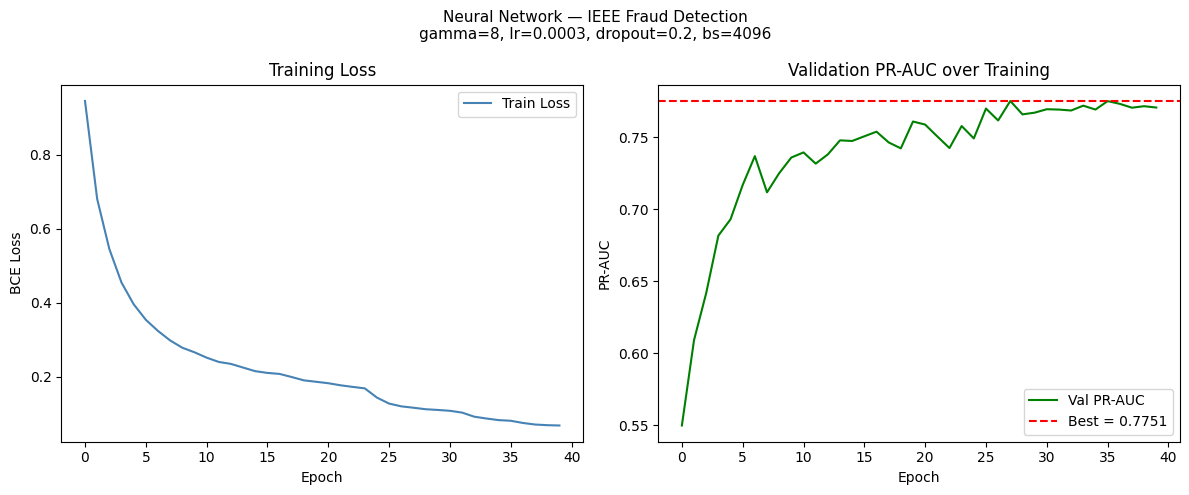

Training curves saved to runs\Jaf's NN (GridSearch, 3 Layer, Leaky ReLU)\nn_training_curves.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(history['train_loss'], label='Train Loss', color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('BCE Loss')
ax.set_title('Training Loss')
ax.legend()

ax = axes[1]
ax.plot(history['val_pr'], label='Val PR-AUC', color='green')
ax.axhline(y=best_val_pr_auc, color='red', linestyle='--', label=f'Best = {best_val_pr_auc:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('PR-AUC')
ax.set_title('Validation PR-AUC over Training')
ax.legend()

cfg_label = f"gamma={gamma}, lr={lr}, dropout={dropout}, bs={batch_size}"
plt.suptitle(f'Neural Network — IEEE Fraud Detection\n{cfg_label}', fontsize=11)
plt.tight_layout()
curves_path = os.path.join(RUN_DIR, 'nn_training_curves.png')
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Training curves saved to {curves_path}")

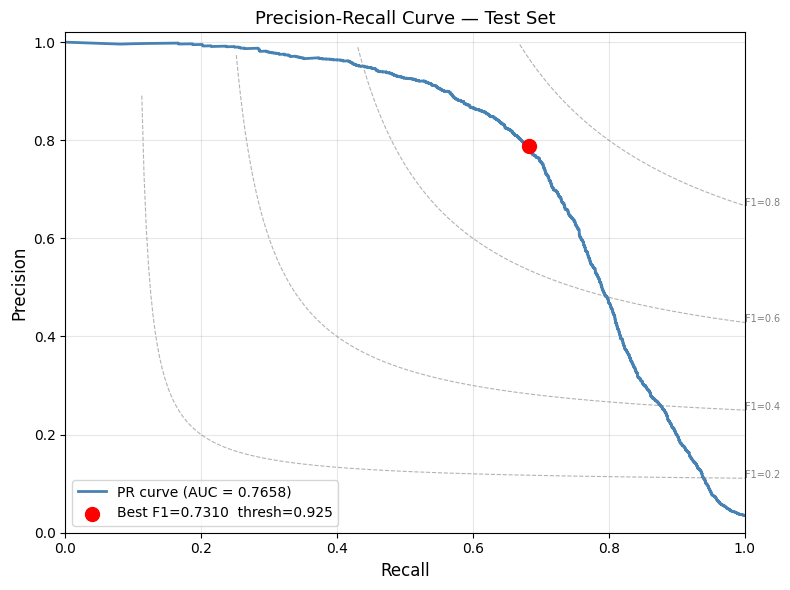

PR curve saved to runs\Jaf's NN (GridSearch, 3 Layer, Leaky ReLU)\pr_curve.png


In [27]:
## PR Curve + best threshold based on f1

y_true, y_proba = get_predictions(model, loader_test)

precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

# F1 at every threshold (precision/recall have one extra trailing point — align)
f1_scores   = (2 * precision_pts[:-1] * recall_pts[:-1]
               / (precision_pts[:-1] + recall_pts[:-1] + 1e-8))
best_idx    = np.argmax(f1_scores)
best_thresh = float(thresholds[best_idx])
best_f1     = float(f1_scores[best_idx])

# Recall and precision at the best-F1 threshold
best_recall    = float(recall_pts[best_idx])
best_precision = float(precision_pts[best_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_pts, precision_pts, color='steelblue', lw=2,
        label=f'PR curve (AUC = {test_pr:.4f})')
ax.scatter(best_recall, best_precision, color='red', zorder=5, s=100,
           label=f'Best F1={best_f1:.4f}  thresh={best_thresh:.3f}')

for f1_iso in [0.2, 0.4, 0.6, 0.8]:
    r_vals = np.linspace(0.01, 1.0, 300)
    p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
    mask   = (p_vals >= 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], '--', color='grey', lw=0.8, alpha=0.6)
    ax.annotate(f'F1={f1_iso}', xy=(r_vals[mask][-1], p_vals[mask][-1]),
                fontsize=7, color='grey')

ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Test Set', fontsize=13)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
pr_curve_path = os.path.join(RUN_DIR, 'pr_curve.png')
plt.savefig(pr_curve_path, dpi=150)
plt.show()
print(f"PR curve saved to {pr_curve_path}")

In [28]:
val_y_true, val_proba = get_predictions(model, loader_val)
val_recall  = recall_score(val_y_true,
                           (val_proba  >= best_thresh).astype(int),
                           zero_division=0)
test_recall = best_recall   # already computed above from PR curve

print(f"\n{'='*50}")
print(f"  Final Results at best threshold = {best_thresh:.3f}")
print(f"{'='*50}")
print(f"  Test PR-AUC  : {test_pr:.4f}")
print(f"  Test F1      : {best_f1:.4f}")
print(f"  Test Recall  : {test_recall:.4f}")
print(f"  Test Precision: {best_precision:.4f}")
print(f"  Val  Recall  : {val_recall:.4f}")

# Append threshold + recall to the saved metrics file
final_metrics = {
    'best_config'    : {'gamma': gamma, 'lr': lr, 'dropout': dropout, 'batch_size': batch_size},
    'val_pr_auc'     : val_pr,
    'test_pr_auc'    : test_pr,
    'best_thresh'    : best_thresh,
    'test_f1'        : best_f1,
    'test_recall'    : test_recall,
    'test_precision' : best_precision,
    'val_recall'     : val_recall,
}
metrics_path = os.path.join(RUN_DIR, 'final_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)
print(f"\nFinal metrics saved to {metrics_path}")


  Final Results at best threshold = 0.925
  Test PR-AUC  : 0.7658
  Test F1      : 0.7310
  Test Recall  : 0.6818
  Test Precision: 0.7878
  Val  Recall  : 0.6738

Final metrics saved to runs\Jaf's NN (GridSearch, 3 Layer, Leaky ReLU)\final_metrics.json


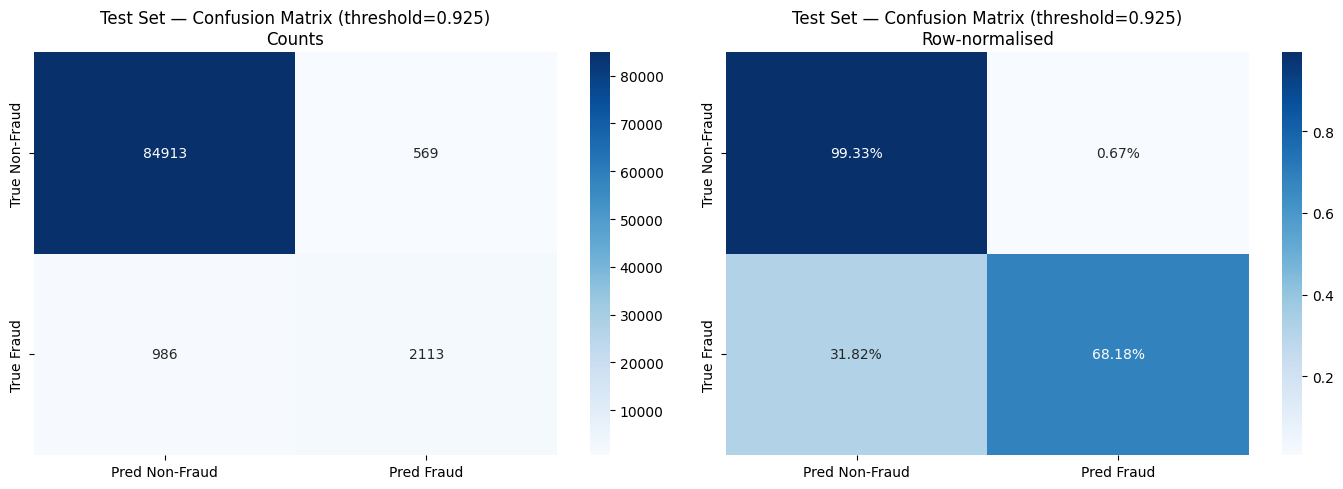


Classification Report (threshold=0.925):
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.79      0.68      0.73      3099

    accuracy                           0.98     88581
   macro avg       0.89      0.84      0.86     88581
weighted avg       0.98      0.98      0.98     88581

Confusion matrix saved to runs\Jaf's NN (GridSearch, 3 Layer, Leaky ReLU)\confusion_matrix.png


In [34]:
# After loading best_state:
plot_confusion_matrix(y_true, y_proba, threshold=best_thresh, save_dir=RUN_DIR)

### Save model

In [36]:
model_path = os.path.join(RUN_DIR, 'nn_model.pt')
torch.save({
    'model_state_dict' : best_state,
    'best_config'      : {'gamma': gamma, 'lr': lr, 'dropout': dropout, 'batch_size': batch_size},
    'val_pr_auc'       : val_pr,
    'test_pr_auc'      : test_pr,
    'best_thresh'      : best_thresh,
    'test_recall'      : test_recall,
    'val_recall'       : val_recall,
    'cat_cols'         : cat_cols,
    'num_cols'         : num_cols,
    'vocab_sizes'      : vocab_sizes,
}, model_path)
print(f"Model saved to {model_path}")

print(f"\n{'='*50}")
print(f"  All outputs saved to: {RUN_DIR}/")
print(f"    nn_training_curves.png")
print(f"    pr_curve.png")
print(f"    confusion_matrix.png")
print(f"    classification_report.txt")
print(f"    training_log.csv")
print(f"    hp_search_results.csv")
print(f"    final_metrics.json")
print(f"    nn_model.pt")
print(f"{'='*50}")

Model saved to runs\Jaf's NN (GridSearch, 3 Layer, Leaky ReLU)\nn_model.pt

  All outputs saved to: runs\Jaf's NN (GridSearch, 3 Layer, Leaky ReLU)/
    nn_training_curves.png
    pr_curve.png
    confusion_matrix.png
    classification_report.txt
    training_log.csv
    hp_search_results.csv
    final_metrics.json
    nn_model.pt
